In [43]:
%pylab inline
import pandas as pd

Populating the interactive namespace from numpy and matplotlib


In [44]:
!wget  -O 'end_seminar-2.xlsx' -q 'https://www.dropbox.com/scl/fi/2ezfw6b3y1umremflbgdl/end_seminar.xlsx?rlkey=xzecol82ybnpu0eon0b1s11pp&st=f45sugvp&dl=0'

zsh:1: command not found: wget


In [45]:
# !powershell iwr -outf somefile https://somesite/somefile

In [46]:
# !pip install wget
# import wget
# wget.download('https://www.dropbox.com/scl/fi/2ezfw6b3y1umremflbgdl/end_seminar.xlsx?rlkey=xzecol82ybnpu0eon0b1s11pp&st=f45sugvp&dl=0', 'end_seminar.xlsx')

In [47]:
# your code
df = pd.read_excel("end_seminar.xlsx")
df.tail()[-3::]

,timestamp,id,rating,group_22,is_mi,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,percentile,group_21,blended,is_ml_student
426,2024-08-19 11:49:43.000,77b2b19d26b7f160c1938369197f7cac590b2e0cfcac3b...,1232,NaN,NaN,Принятие решений в условиях риска и неопределе...,Основы разработки компьютерных игр,Введение в платформы данных,Теория и практика онлайн-экспериментов,Конфликты и кооперация (преподается на английс...,Децентрализованные системы,Да,0.440252,212.0,Соревновательный анализ данных,NaN
427,2024-08-13 14:58:30.000,6dafd9a56d08aeb419166d314b0cd6f3107ae5e8dbd636...,961,NaN,NaN,Основы информационного поиска,Дизайн систем,Язык программирования Scala,Промышленное программирование на Haskell,Методы сжатия и передачи медиаданных,Децентрализованные системы,Да,0.858491,215.0,Безопасность систем на базе LLM,NaN
428,2024-08-13 18:35:25.235,4bf710d7b89064e1a3cbcc69b7ca67c20d6181dc72ad35...,1374,NaN,NaN,Трансформерные и мультимодальные модели,Глубинное обучение для текстовых данных,Self-supervised Learning,Обучение с подкреплением,Современные языковые модели,Развёртывание ML-моделей в высоконагруженных с...,Да,0.169811,217.0,Продуктовый подход к анализу данных,NaN


In [48]:
# your code
group_22_list = df[df['group_22'].notnull()]['id'].unique()
print(len(group_22_list))

group_21_list = df[df['group_21'].notnull()]['id'].unique()
print(len(group_21_list))

259
159


In [49]:
# your code
unique_students = df.drop_duplicates('id')

duplicated_percentile = unique_students[unique_students['percentile'].duplicated(False)].sort_values('percentile')
duplicated_percentile[['id', 'percentile']]

,id,percentile
336,92f4503e31c17e957f5c5ce045c496f440b0565d37f9aa...,0.000000
131,43356e961c7491ef55887c470a7d1fcb69e62000fdf660...,0.000000
257,be9535b2b536b657f56210df5274fe9127cbfeb0303844...,0.035185
262,60553144cbe31126977f8493bb151028cc76e0112f5437...,0.035185
414,3982de41a556b0c4d824494e28c35a5f235ce3c6c191c4...,0.053459
...,...,...
92,44c9ac59a9323780b2b4e08982dd2b53a54bebc05d817d...,0.962963
81,69880c9dee0394bce1c503024d7fc64afad25fddb8981b...,0.962963
359,cdb87f7b15495e514eb481230b44540c6b0cfeb347c991...,0.987421
339,6fa015d8846e21f4f79bac013b469a1e6e962fffd6121b...,0.987421


In [50]:
# your code
df.isna().sum()

timestamp          0
id                 0
rating             0
group_22         159
is_mi            403
fall_1             0
fall_2             0
fall_3             0
spring_1          48
spring_2          48
spring_3          48
is_first_time      0
percentile         0
group_21         270
blended          270
is_ml_student    254
dtype: int64

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      429 non-null    datetime64[ns]
 1   id             429 non-null    object        
 2   rating         429 non-null    int64         
 3   group_22       270 non-null    float64       
 4   is_mi          26 non-null     float64       
 5   fall_1         429 non-null    object        
 6   fall_2         429 non-null    object        
 7   fall_3         429 non-null    object        
 8   spring_1       381 non-null    object        
 9   spring_2       381 non-null    object        
 10  spring_3       381 non-null    object        
 11  is_first_time  429 non-null    object        
 12  percentile     429 non-null    float64       
 13  group_21       159 non-null    float64       
 14  blended        159 non-null    object        
 15  is_ml_student  175 non-

In [52]:
# your code
type_float = df.select_dtypes(include='float64').fillna(0)
type_object = df.select_dtypes(include='object').fillna('')
type_bool = df.select_dtypes(include='bool').fillna(False)
type_other = df.select_dtypes(exclude=['float64', 'object', 'bool'])

df = pd.concat([type_other, type_float, type_object, type_bool], axis=1)

df

,timestamp,rating,group_22,is_mi,percentile,group_21,is_ml_student,id,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,blended
0,2024-08-12 00:01:06.000,737,226.0,0.0,0.144444,0.0,0.0,8a95d7276b95b8b9c4cf8a5b402e98617ad7452977f6e6...,Разработка микросервисов на Go,Язык SQL,Распределенные системы,Компьютерные сети,Язык программирования Go,Промышленное программирование на языке Java,Да,
1,2024-08-14 00:00:22.000,486,2210.0,0.0,0.796296,0.0,1.0,289897d0cf42b4b42c50300f94b8b86f913174ae972d96...,Распределенные системы,Основы информационного поиска,Основы разработки компьютерных игр,Рекомендательные системы,Дополнительные главы машинного обучения,Стохастический анализ,Да,
2,2024-08-13 18:16:33.000,494,223.0,0.0,0.774074,0.0,1.0,01f548f29a80a6f35b8ce1bdfdf723e2ba70a9c074c2f9...,Statistical Learning Theory,Распределенные системы,Основы тензорных вычислений,Стохастический анализ,Специальные разделы матричного анализа,Математические основы нейросетевых моделей,Да,
3,2024-08-14 10:22:37.000,753,225.0,0.0,0.096296,0.0,0.0,68e3e62f6e017e43094bb63b4dde0b0229564cece838b5...,Разработка микросервисов на Go,Язык SQL,Безопасность компьютерных систем,Промышленное программирование на языке Java,Промышленное программирование на языке Java,Промышленное программирование на языке Java,Да,
4,2024-08-14 20:52:05.000,685,221.0,0.0,0.275926,0.0,1.0,aac63ca42c5701a219d0e4f3289e17ed3160d5a2279790...,Типы в языках программирования,Основы информационного поиска,Системы баз данных,Дополнительные главы машинного обучения,Генеративные модели в машинном обучении (углуб...,Моделирование временных рядов,Да,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424,2024-08-14 11:18:13.362,1160,0.0,0.0,0.553459,216.0,0.0,626f3ae963a471fc69b71e2f5ac3f5f8de93c37c8d6bf0...,Дизайн систем,Операционные системы 2,Основы информационного поиска,Промышленное программирование на Haskell,Децентрализованные системы,Методы сжатия и передачи медиаданных,Да,Протоколы доказательств с нулевым разглашением
425,2024-08-14 21:40:08.000,999,0.0,0.0,0.795597,215.0,0.0,07816e53236a6a9993a3b100de9899fc601feb555445b2...,Основы информационного поиска,Введение в платформы данных,Язык программирования Scala,Промышленное программирование на Haskell,Методы сжатия и передачи медиаданных,Обучение с подкреплением,Да,Безопасность систем на базе LLM
426,2024-08-19 11:49:43.000,1232,0.0,0.0,0.440252,212.0,0.0,77b2b19d26b7f160c1938369197f7cac590b2e0cfcac3b...,Принятие решений в условиях риска и неопределе...,Основы разработки компьютерных игр,Введение в платформы данных,Теория и практика онлайн-экспериментов,Конфликты и кооперация (преподается на английс...,Децентрализованные системы,Да,Соревновательный анализ данных
427,2024-08-13 14:58:30.000,961,0.0,0.0,0.858491,215.0,0.0,6dafd9a56d08aeb419166d314b0cd6f3107ae5e8dbd636...,Основы информационного поиска,Дизайн систем,Язык программирования Scala,Промышленное программирование на Haskell,Методы сжатия и передачи медиаданных,Децентрализованные системы,Да,Безопасность систем на базе LLM


In [53]:
df.isna().sum()

timestamp        0
rating           0
group_22         0
is_mi            0
percentile       0
group_21         0
is_ml_student    0
id               0
fall_1           0
fall_2           0
fall_3           0
spring_1         0
spring_2         0
spring_3         0
is_first_time    0
blended          0
dtype: int64

In [54]:
df.groupby('is_first_time').size()

is_first_time
Да     407
Нет     22
dtype: int64

In [55]:
df.groupby('is_first_time').size() / len(df) * 100

is_first_time
Да     94.871795
Нет     5.128205
dtype: float64

In [56]:
students_last_list = df.groupby(['id'], as_index=False)['timestamp'].max()
df = students_last_list.merge(df, on=['id', 'timestamp'],  how='left')


In [57]:
df = df.drop_duplicates('id')

In [58]:
df = df.drop(columns='is_mi')

In [59]:
df

,id,timestamp,rating,group_22,percentile,group_21,is_ml_student,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,blended
0,0059ff585d5dd682c681c52e0bffb9d0c2a259d2a3f71c...,2024-08-13 21:27:21.000,522,229.0,0.701852,0.0,0.0,Системы баз данных,Системы баз данных,Системы баз данных,Компьютерные сети,Компьютерные сети,Компьютерные сети,Да,
1,01d7c005dacd8c0be29bae8672b92be43c8cd0bd5b0af9...,2024-08-14 10:27:31.000,1030,0.0,0.754717,211.0,1.0,Глубинное обучение в обработке звука,Self-supervised Learning,Глубинное обучение для текстовых данных,Обучение с подкреплением,Теория и практика онлайн-экспериментов,Математические основы нейросетевых моделей,Да,ML System Design
2,01f548f29a80a6f35b8ce1bdfdf723e2ba70a9c074c2f9...,2024-08-13 18:16:33.000,494,223.0,0.774074,0.0,1.0,Statistical Learning Theory,Распределенные системы,Основы тензорных вычислений,Стохастический анализ,Специальные разделы матричного анализа,Математические основы нейросетевых моделей,Да,
3,027ed85baa13164987f5c30f6e4bdcb9c8f6566ca2d09d...,2024-08-14 15:18:51.000,696,222.0,0.250000,0.0,0.0,Разработка микросервисов на Go,Безопасность компьютерных систем,Основы информационного поиска,Аналитика данных,Машинное обучение в прикладных задачах,Дополнительные главы машинного обучения,Да,
4,0371f1e9746b55e981d200dbc94929d95e6629295cbe43...,2024-08-13 19:26:10.000,547,225.0,0.631481,0.0,0.0,Распределенные системы,Statistical Learning Theory,Разработка микросервисов на Go,,,,Да,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,fd9e56667275c376fd4349cbc7d049bf77d0602a6b3aac...,2024-08-13 22:56:34.000,650,229.0,0.353704,0.0,1.0,Язык SQL,Statistical Learning Theory,Основы тензорных вычислений,Генеративные модели в машинном обучении (углуб...,Машинное обучение в прикладных задачах,Стохастический анализ,Да,
424,fe90aa7a0896204cfb47d3fa8c5ee079a22a1f900b6755...,2024-08-14 21:37:11.000,561,229.0,0.587037,0.0,1.0,Statistical Learning Theory,Основы информационного поиска,Язык SQL,Дополнительные главы машинного обучения,Машинное обучение в прикладных задачах,Аналитика данных,Да,
425,ff2b57429d0d45788e2e22cf0c13fe152ef7a8e41f480f...,2024-08-14 22:39:30.429,915,0.0,0.955975,215.0,0.0,Операционные системы 2,Дизайн систем,Безопасность компьютерных систем,Развёртывание ML-моделей в высоконагруженных с...,Децентрализованные системы,Промышленное программирование на Haskell,Да,Протоколы доказательств с нулевым разглашением
426,ffe30e6b61eb3a819223305e77c276da9c373aa4a8763f...,2024-08-14 14:42:14.000,697,227.0,0.244444,0.0,0.0,Безопасность компьютерных систем,Прикладная статистика в машинном обучении,Основы информационного поиска,,,,Да,


In [60]:
# your code
blended_courses_list = df[df['blended'] != '']['blended'].unique()
print(blended_courses_list)


['ML System Design' 'Соревновательный анализ данных'
 'Безопасность систем на базе LLM'
 'Протоколы доказательств с нулевым разглашением'
 'Введение в дифференциальную геометрию'
 'Продуктовый подход к анализу данных']


In [61]:
df[df['blended'] != '']['blended'].value_counts()

Протоколы доказательств с нулевым разглашением    44
ML System Design                                  38
Соревновательный анализ данных                    26
Продуктовый подход к анализу данных               25
Безопасность систем на базе LLM                   13
Введение в дифференциальную геометрию             13
Name: blended, dtype: int64

In [62]:
print('Протоколы доказательств с нулевым разглашением =', df[df['blended'] == 'Протоколы доказательств с нулевым разглашением']['rating'].mean())
print('ML System Design =', df[df['blended'] == 'ML System Design']['rating'].mean())
print('Соревновательный анализ данных =', df[df['blended'] == 'Соревновательный анализ данных']['rating'].mean())
print('Продуктовый подход к анализу данных =', df[df['blended'] == 'Продуктовый подход к анализу данных']['rating'].mean())
print('Безопасность систем на базе LLM =', df[df['blended'] == 'Безопасность систем на базе LLM']['rating'].mean())
print('Введение в дифференциальную геометрию =', df[df['blended'] == 'Введение в дифференциальную геометрию']['rating'].mean())

Протоколы доказательств с нулевым разглашением = 1146.5
ML System Design = 1202.3157894736842
Соревновательный анализ данных = 1207.8461538461538
Продуктовый подход к анализу данных = 1249.28
Безопасность систем на базе LLM = 1163.3076923076924
Введение в дифференциальную геометрию = 1138.5384615384614


In [63]:
list_by_courses = df.groupby(['fall_1', 'fall_2', 'fall_3', 'spring_1', 'spring_2', 'spring_3', 'blended'])
list_num_students = list_by_courses.size().reset_index(name='num')
list_more_1 = list_num_students.query('num > 1')

In [64]:
list_more_1

,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,blended,num
13,Statistical Learning Theory,Основы информационного поиска,Язык SQL,Дополнительные главы машинного обучения,Машинное обучение в прикладных задачах,Аналитика данных,,2
60,Безопасность компьютерных систем,Основы разработки компьютерных игр,Язык SQL,Компьютерные сети,Компьютерные сети,Компьютерные сети,,2
134,Дизайн систем,Безопасность компьютерных систем,Основы разработки компьютерных игр,Децентрализованные системы,Методы сжатия и передачи медиаданных,Теория и практика онлайн-экспериментов,Протоколы доказательств с нулевым разглашением,2
135,Дизайн систем,Безопасность компьютерных систем,Основы разработки компьютерных игр,Децентрализованные системы,Промышленное программирование на Haskell,Обучение с подкреплением,Протоколы доказательств с нулевым разглашением,2
142,Дизайн систем,Операционные системы 2,Основы информационного поиска,Промышленное программирование на Haskell,Децентрализованные системы,Методы сжатия и передачи медиаданных,Протоколы доказательств с нулевым разглашением,2
282,Системы баз данных,Операционные системы 2,Безопасность компьютерных систем,,,,,2
288,Системы баз данных,Операционные системы 2,Разработка микросервисов на Go,,,,,2
290,Системы баз данных,Операционные системы 2,Разработка микросервисов на Go,Компьютерные сети,Компьютерные сети,Компьютерные сети,,2
293,Системы баз данных,Операционные системы 2,Функциональное программирование,,,,,2
309,Системы баз данных,Разработка микросервисов на Go,Операционные системы 2,Компьютерные сети,Промышленное программирование на языке Java,Машинное обучение 2,,2


In [65]:
# your code
courses_22 = set(set(df[df['group_22'] != 0]['fall_1'].unique()) | \
        set(df[df['group_22'] != 0]['fall_2'].unique()) | \
        set(df[df['group_22'] != 0]['fall_3'].unique()) | \
        set(df[df['group_22'] != 0]['spring_1'].unique()) | \
        set(df[df['group_22'] != 0]['spring_2'].unique()) | \
        set(df[df['group_22'] != 0]['spring_3'].unique()))

courses_21 = set(set(df[df['group_21'] != 0]['fall_1'].unique()) | \
        set(df[df['group_21'] != 0]['fall_2'].unique()) | \
        set(df[df['group_21'] != 0]['fall_3'].unique()) | \
        set(df[df['group_21'] != 0]['spring_1'].unique()) | \
        set(df[df['group_21'] != 0]['spring_2'].unique()) | \
        set(df[df['group_21'] != 0]['spring_3'].unique()))

courses_22_21 = courses_21 & courses_22

print(len(courses_22_21))
print(courses_22_21)


14
{'Введение в платформы данных', 'Основы разработки компьютерных игр', 'Математические основы нейросетевых моделей', 'Специальные разделы матричного анализа', 'Типы в языках программирования', 'Операционные системы 2', 'Принятие решений в условиях риска и неопределенности', 'Основы информационного поиска', 'Язык программирования Scala', 'Стохастический анализ', 'Statistical Learning Theory', 'Основы тензорных вычислений', 'Интегральные уравнения в задачах математического моделирования', 'Безопасность компьютерных систем'}


In [66]:
# your code
courses_22_only = courses_22 - courses_22_21
print(sorted(courses_22_only))

courses_21_only = courses_21 - courses_22_21
print(sorted(courses_21_only))


['', 'Go от шада', 'Аналитика данных', 'Генеративные модели в машинном обучении (углубленный курс)', 'Глубинное обучение в естественных науках', 'Дополнительные главы машинного обучения', 'Количественные финансы', 'Комбинаторная оптимизация', 'Компьютерные сети', 'Лингвистика для программистов', 'Машинное обучение 2', 'Машинное обучение в прикладных задачах', 'Моделирование временных рядов', 'Прикладная статистика в машинном обучении', 'Промышленное программирование на языке Java', 'Разработка микросервисов на Go', 'Распределенные системы', 'Рекомендательные системы', 'Системы баз данных', 'Топологический анализ данных', 'Функциональное программирование', 'ШАД RL', 'Шадовский Go', 'Язык SQL', 'Язык программирования Go']
['Self-supervised Learning', 'Байесовские методы в машинном обучении', 'Генеративные модели в машинном обучении', 'Генеративные модели на основе диффузии', 'Генеративные модели на основе диффузии / Diffusion-Based Generative Models', 'Глубинное обучение в анализе графов

Видите ли вы что-то необычное в получившихся списках? (менять ничего не нужно, просто подумайте)

**Ответ:**
Два раза упомниается 'Генеративные модели на основе диффузии' и 'Генеративные модели на основе диффузии / Diffusion-Based Generative Models'. По факту это один курс, но названия различаются

### Визуализации и matplotlib

In [67]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# your code
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 8, 5
plt.rcParams['font.size'] = 12
mpl.rcParams['savefig.format'] = 'pdf'
sns.set_style('darkgrid')

In [68]:
datetimes = pd.to_datetime(df['timestamp']).dt.date
day_and_rating = df.groupby(datetimes)['rating'].mean()

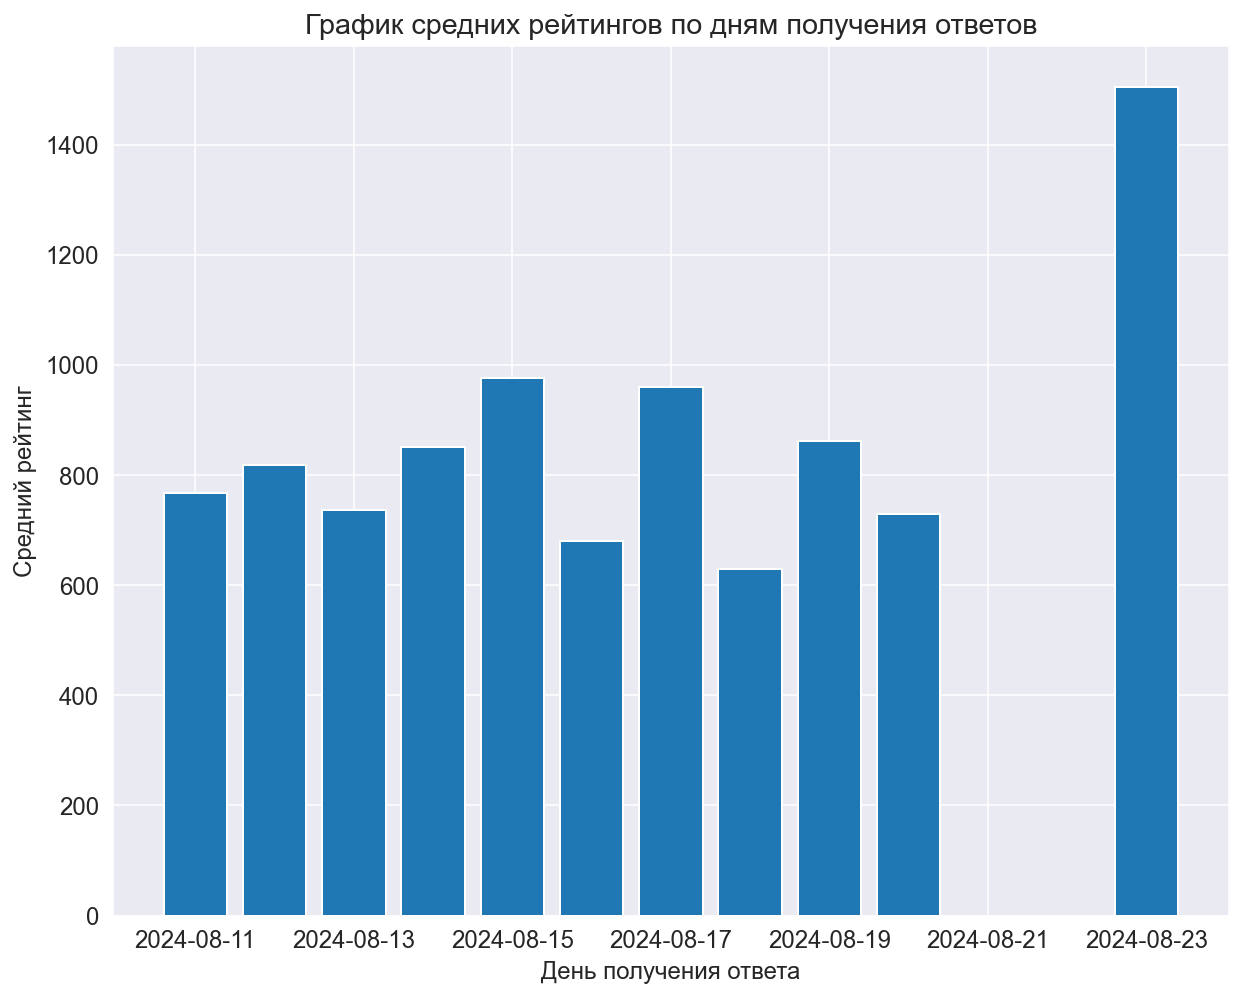

In [69]:
# your code
fig, ax = plt.subplots(figsize=(10,8))
days = day_and_rating.index
rating = day_and_rating.values
plt.bar(days, rating)

ax.set(xlabel='День получения ответа')
ax.set(ylabel='Средний рейтинг')
plt.title('График средних рейтингов по дням получения ответов')
plt.savefig("my_plot.pdf", format="pdf") 
plt.show()

Сохраните график в формате pdf (так он останется векторизованным).

In [70]:
# your code
#в предыдущей ячейке кода сохранила

In [71]:
assert df.shape == (418, 15), 'В таблице остались повторы или потеряны данные'
assert df.isna().sum().sum() == 0, 'В таблице остались пропуски'

In [72]:
# (￣^￣)ゞ
def foo(student_id):
    tmp = df['id'] == student_id
    student_index = df[tmp].index

    if df.loc[student_index[0], 'group_22'] != 0:
        student_group = df.loc[student_index[0], 'group_22']
        df.loc[student_index[0], 'num_of_courses_fall'] = 1
    else:
        student_group = df.loc[student_index[0], 'group_21']
        if student_group == 211 or student_group == 212 or student_group == 213:
            df.loc[student_index[0], 'num_of_courses_fall'] = 2
        else:
            df.loc[student_index[0], 'num_of_courses_fall'] = 1

for i in range(len(df)):
    student_id = df.iloc[i]['id']
    foo(student_id)

In [73]:
col_name = 'num_of_courses_fall' # insert your new column name as str

assert(df[df['id'] == 'bcca318e644999583156ff3ab9de3d6bd02295dcb166e39006568ffe9582207b'][col_name] == 1).all()
assert(df[df['id'] == 'edb64996c64421378537d941a77426a5a7bd84f9967ad9f523ca61386e5469ed'][col_name] == 1).all()
assert(df[df['id'] == '5f96908e3ce5d84d693ddd79670d60cd1c6a02646aa779f46586a7699dda7c25'][col_name] == 1).all()
assert(df[df['id'] == '0f137538a170b64258c0e10839cadc325e5f22fc5bb5fa9e20b7351f0a680366'][col_name] == 2).all()

In [74]:
def check_percentile(arr):
    new_arr = []
    for i in range(len(arr)):
        tmp = df['id'] == arr[i]
        student_index = df[tmp].index
        new_arr.append((arr[i], df.loc[student_index[0], 'percentile']))
    
    new_arr = sorted(new_arr, key=lambda x: x[1])
    ans = []
    for i in range(len(new_arr)):
        ans.append(new_arr[i][0])

    return ans


In [75]:
# (￣^￣)ゞ
courses_dict = dict()
all_courses = courses_22 | courses_21

for i in range(len(df)):
    student_1p = df.iloc[i]['fall_1']
    is_22 = (df.iloc[i]['group_22'] != 0)
    is_21 = (df.iloc[i]['group_21'] != 0)
    student_id = df.iloc[i]['id']

    for course_name in all_courses:
        if is_22:
            if course_name == student_1p:
                if course_name in courses_dict:
                    courses_dict[course_name].append(student_id)
                else:
                    courses_dict[course_name] = []
                    courses_dict[course_name].append(student_id)
        if is_21:
            if df.iloc[i]['group_21'] == 211 or df.iloc[i]['group_21'] == 212 or df.iloc[i]['group_21'] == 213:
                student_2p = df.iloc[i]['fall_2']
                if (course_name == student_1p) or (course_name == student_2p):
                    if course_name in courses_dict:
                        courses_dict[course_name].append(student_id)
                    else:
                        courses_dict[course_name] = []
                        courses_dict[course_name].append(student_id)
            else:
                if course_name == student_1p:
                    if course_name in courses_dict:
                        courses_dict[course_name].append(student_id)
                    else:
                        courses_dict[course_name] = []
                        courses_dict[course_name].append(student_id)


        
best = set()
worst = set()

for course in courses_dict:
    if course == "Количественные финансы":
        new_arr = check_percentile(courses_dict[course])
        if len(courses_dict[course]) >= 60:
            courses_dict[course] = new_arr[:60]
            best.add(courses_dict[course][0])
            worst.add(courses_dict[course][-1])
        else:
            best.add(new_arr[0])
            worst.add(new_arr[-1])


    elif course == "Промышленное программирование на Haskell":
        new_arr = check_percentile(courses_dict[course])
        if len(courses_dict[course]) >= 60:
            courses_dict[course] = new_arr[:60]
            best.add(courses_dict[course][0])
            worst.add(courses_dict[course][-1])
        else:
            best.add(new_arr[0])
            worst.add(new_arr[-1])

    elif course == "Рекомендательные системы":
        new_arr = check_percentile(courses_dict[course])
        if len(courses_dict[course]) >= 60:
            courses_dict[course] = new_arr[:60]
            best.add(courses_dict[course][0])
            worst.add(courses_dict[course][-1])
        else:
            best.add(new_arr[0])
            worst.add(new_arr[-1])

    elif course == "Глубинное обучение в обработке звука":
        new_arr = check_percentile(courses_dict[course])
        if len(courses_dict[course]) >= 1000:
            courses_dict[course] = new_arr[:1000]
            best.add(courses_dict[course][0])
            worst.add(courses_dict[course][-1])
        else:
            best.add(new_arr[0])
            worst.add(new_arr[-1])

    else:
        new_arr = check_percentile(courses_dict[course])
        if len(courses_dict[course]) >= 30:
            courses_dict[course] = new_arr[:30]
            best.add(courses_dict[course][0])
            worst.add(courses_dict[course][-1])
        else:
            best.add(new_arr[0])
            worst.add(new_arr[-1])

df['course_1'] = NaN
df['course_2'] = NaN
df['is_first_place'] = NaN
df['is_last_place'] = NaN



for course in courses_dict:
    for student_id in courses_dict[course]:
        tmp = df['id'] == student_id
        student_index = df[tmp].index

        if df.loc[student_index[0], 'num_of_courses_fall'] == 1:
            df.loc[student_index[0], 'course_1'] = course
        else:
            if pd.isna(df.loc[student_index[0], 'course_1']):
                df.loc[student_index[0], 'course_1'] = course
            else:
                df.loc[student_index[0], 'course_2'] = course

        if student_id in best:
            df.loc[student_index[0], 'is_first_place'] = True
        if student_id in worst:
            df.loc[student_index[0], 'is_last_place'] = True
            

In [76]:
!wget  -O '2_task_check.csv' -q 'https://www.dropbox.com/scl/fi/ixodhpl9xxhdb6a9fqglm/2_task_check.csv?rlkey=53c6ea92rkrz2057tfv7trdxo&st=13lp5ley&dl=0'
check_df = pd.read_csv('2_task_check.csv')

zsh:1: command not found: wget


In [77]:
fir_col_name = 'is_first_place'   # insert name of your new column with is_first_place as str
last_col_name = 'is_last_place'     # insert name of your new column with is_last_place as str


assert((df[df['is_first_place'].isna() == False][['id']].sort_values('id').reset_index(drop=True)
        ==
        check_df[check_df['is_first_place'].isna() == False][['id']].sort_values('id').reset_index(drop=True)
       ).id.values).all()

In [78]:
#assert((df[df['is_last_place'].isna() == False][['id']].sort_values('id').reset_index(drop=True)
       #==
       #check_df[check_df['is_last_place'].isna() == False][['id']].sort_values('id').reset_index(drop=True)
      #).id.values).all()

In [79]:
available_course = dict()
for course in courses_dict:
    if course == "Количественные финансы" or course == "Промышленное программирование на Haskell" or course == "Рекомендательные системы":
        if len(courses_dict[course]) < 60:
            if course not in available_course:
                available_course[course] = []
    elif course == "Глубинное обучение в обработке звука":
        if len(courses_dict[course]) < 1000:
            if course not in available_course:
                available_course[course] = []
    else:
        if len(courses_dict[course]) < 30:
            if course not in available_course:
                available_course[course] = []

In [80]:
available_courses = dict()
for course in courses_dict:
    if course == "Количественные финансы" or course == "Промышленное программирование на Haskell" or course == "Рекомендательные системы":
        if len(courses_dict[course]) < 60:
            if course not in available_courses:
                available_courses[course] = [60 - len(courses_dict[course])]
    elif course == "Глубинное обучение в обработке звука":
        if len(courses_dict[course]) < 1000:
            if course not in available_courses:
                available_courses[course] = [1000 - len(courses_dict[course])]
    else:
        if len(courses_dict[course]) < 30:
            if course not in available_courses:
                available_courses[course] = [30 - len(courses_dict[course])]

In [81]:
# (￣^￣)ゞ
new_students_list = []

for i in range(len(df)):
    student_course_1 = df.iloc[i]['course_1']
    student_course_2 = df.iloc[i]['course_2']
    if pd.isna(student_course_1):
        student_id = df.iloc[i]['id']
        new_students_list.append(student_id)
    elif pd.isna(student_course_2) and df.iloc[i]['num_of_courses_fall'] == 2:
        student_id = df.iloc[i]['id']
        new_students_list.append(student_id)

In [82]:
for i in range(len(new_students_list)):
    student_id = new_students_list[i]
    student_data = df[df['id'] == student_id]
    is_mop_21 = (student_data.iloc[0]['num_of_courses_fall'] == 2)
    studen_row = student_data.iloc[0]

    for course_name in available_courses:
        if is_mop_21:
            student_2p = studen_row['fall_3']
            if course_name == student_2p:
                available_courses[course_name].append(student_id)
        else:
            student_2p = studen_row['fall_2']
            if course_name == student_2p:
                available_courses[course_name].append(student_id)
       

In [83]:
for course in available_courses:
    num = available_courses[course][0]
    if len(available_courses[course][1:]) > num:
        new_arr = check_percentile(available_courses[course][1:])
        available_courses[course] = new_arr[:num]
    else:
        available_courses[course] = available_courses[course][1:]

In [84]:
for course in available_courses:
    for student_id in available_courses[course]:
        tmp = df['id'] == student_id
        student_index = df[tmp].index

        if pd.isna(df.loc[student_index[0], 'course_1']):
            df.loc[student_index[0], 'course_1'] = course
        else:
            df.loc[student_index[0], 'course_2'] = course

In [85]:
available_courses_3 = dict()
for course in available_courses:
    if course == "Количественные финансы" or course == "Промышленное программирование на Haskell" or course == "Рекомендательные системы":
        if len(available_courses[course]) < 60:
            if course not in available_courses_3:
                available_courses_3[course] = [60 - len(available_courses[course]) - len(courses_dict[course])]
    elif course == "Глубинное обучение в обработке звука":
        if len(available_courses[course]) < 1000:
            if course not in available_courses_3:
                available_courses_3[course] = [1000 - len(available_courses[course]) - len(courses_dict[course])]
    else:
        if len(available_courses[course]) < 30:
            if course not in available_courses_3:
                available_courses_3[course] = [30 - len(available_courses[course]) - len(courses_dict[course])]

In [86]:
new_students_list_3 = []

for i in range(len(df)):
    student_course_1 = df.iloc[i]['course_1']
    student_course_2 = df.iloc[i]['course_2']
    if pd.isna(student_course_1):
        student_id = df.iloc[i]['id']
        new_students_list_3.append(student_id)


In [87]:
for i in range(len(new_students_list_3)):
    student_id = new_students_list_3[i]
    student_data = df[df['id'] == student_id]
    studen_row = student_data.iloc[0]

    for course_name in available_courses_3:
        student_2p = studen_row['fall_3']
        if course_name == student_2p:
            available_courses_3[course_name].append(student_id)

In [88]:
for course in available_courses_3:
    num = available_courses_3[course][0]
    if len(available_courses_3[course][1:]) > num:
        new_arr = check_percentile(available_courses_3[course][1:])
        available_courses_3[course] = new_arr[:num]
    else:
        available_courses_3[course] = available_courses_3[course][1:]

In [89]:
for course in available_courses_3:
    for student_id in available_courses_3[course]:
        tmp = df['id'] == student_id
        student_index = df[tmp].index

        if pd.isna(df.loc[student_index[0], 'course_1']):
            df.loc[student_index[0], 'course_1'] = course

In [90]:
for i in range(len(df)):
    idx = df.index[i]
    
    student_course_1 = df.loc[idx, 'course_1']
    student_course_2 = df.loc[idx, 'course_2']
    is_mop_21 = (df.loc[idx, 'num_of_courses_fall'] == 2)

    if not is_mop_21:
        if pd.isna(student_course_1):
            df.loc[idx, 'course_1'] = '???'
        df.loc[idx, 'course_2'] = '-'
    else:
        if pd.isna(student_course_1):
            df.loc[idx, 'course_1'] = '???'
        if pd.isna(student_course_2):
            df.loc[idx, 'course_2'] = '???'

In [91]:
df[['id', 'course_1', 'course_2']].to_csv('res_fall.csv', index=None, header=['ID', 'course1', 'course2'])

In [92]:
for i in range(len(df)):
    index = df.index[i]

    if df.loc[idx, 'is_ml_student'] == 1 or df.loc[idx, 'group_21'] == 211 or df.loc[idx, 'group_21'] == 212 or df.loc[idx, 'group_21'] == 213:
        if df.loc[idx, 'spring_1'] == "Машинное обучение 2":
            df.loc[idx, 'spring_1'] = df.loc[idx, 'spring_2']
            df.loc[idx, 'spring_2'] = df.loc[idx, 'spring_3']
        if df.loc[idx, 'spring_2'] == "Машинное обучение 2":
            df.loc[idx, 'spring_2'] = df.loc[idx, 'spring_3']
            df.loc[idx, 'spring_3'] = ""
        if df.loc[idx, 'spring_3'] == "Машинное обучение 2":
            df.loc[idx, 'spring_3'] = ""
        
    

In [93]:
# (￣^'￣)ゞ
courses_dict = dict()
all_courses = courses_22 | courses_21

for i in range(len(df)):
    student_1p = df.iloc[i]['spring_1']
    is_22 = (df.iloc[i]['group_22'] != 0)
    is_21 = (df.iloc[i]['group_21'] != 0)
    student_id = df.iloc[i]['id']

    for course_name in all_courses:
        if is_22:
            if course_name == student_1p:
                if course_name in courses_dict:
                    courses_dict[course_name].append(student_id)
                else:
                    courses_dict[course_name] = []
                    courses_dict[course_name].append(student_id)
        if is_21:
            if df.iloc[i]['group_21'] == 211 or df.iloc[i]['group_21'] == 212 or df.iloc[i]['group_21'] == 213:
                student_2p = df.iloc[i]['spring_2']
                if (course_name == student_1p) or (course_name == student_2p):
                    if course_name in courses_dict:
                        courses_dict[course_name].append(student_id)
                    else:
                        courses_dict[course_name] = []
                        courses_dict[course_name].append(student_id)
            else:
                if course_name == student_1p:
                    if course_name in courses_dict:
                        courses_dict[course_name].append(student_id)
                    else:
                        courses_dict[course_name] = []
                        courses_dict[course_name].append(student_id)


for course in courses_dict:
    if course == "Количественные финансы":
        new_arr = check_percentile(courses_dict[course])
        if len(courses_dict[course]) >= 60:
            courses_dict[course] = new_arr[:60]


    elif course == "Промышленное программирование на Haskell":
        new_arr = check_percentile(courses_dict[course])
        if len(courses_dict[course]) >= 60:
            courses_dict[course] = new_arr[:60]

    elif course == "Рекомендательные системы":
        new_arr = check_percentile(courses_dict[course])
        if len(courses_dict[course]) >= 60:
            courses_dict[course] = new_arr[:60]

    elif course == "Глубинное обучение в обработке звука":
        new_arr = check_percentile(courses_dict[course])
        if len(courses_dict[course]) >= 1000:
            courses_dict[course] = new_arr[:1000]

    else:
        new_arr = check_percentile(courses_dict[course])
        if len(courses_dict[course]) >= 30:
            courses_dict[course] = new_arr[:30]

df['course_1_spring'] = NaN
df['course_2_spring'] = NaN



for course in courses_dict:
    for student_id in courses_dict[course]:
        tmp = df['id'] == student_id
        student_index = df[tmp].index

        if df.loc[student_index[0], 'num_of_courses_fall'] == 1:
            df.loc[student_index[0], 'course_1_spring'] = course
        else:
            if pd.isna(df.loc[student_index[0], 'course_1_spring']):
                df.loc[student_index[0], 'course_1_spring'] = course
            else:
                df.loc[student_index[0], 'course_2_spring'] = course
            

In [94]:
available_course = dict()
for course in courses_dict:
    if course == "Количественные финансы" or course == "Промышленное программирование на Haskell" or course == "Рекомендательные системы":
        if len(courses_dict[course]) < 60:
            if course not in available_course:
                available_course[course] = []
    elif course == "Глубинное обучение в обработке звука":
        if len(courses_dict[course]) < 1000:
            if course not in available_course:
                available_course[course] = []
    else:
        if len(courses_dict[course]) < 30:
            if course not in available_course:
                available_course[course] = []


available_courses = dict()
for course in courses_dict:
    if course == "Количественные финансы" or course == "Промышленное программирование на Haskell" or course == "Рекомендательные системы":
        if len(courses_dict[course]) < 60:
            if course not in available_courses:
                available_courses[course] = [60 - len(courses_dict[course])]
    elif course == "Глубинное обучение в обработке звука":
        if len(courses_dict[course]) < 1000:
            if course not in available_courses:
                available_courses[course] = [1000 - len(courses_dict[course])]
    else:
        if len(courses_dict[course]) < 30:
            if course not in available_courses:
                available_courses[course] = [30 - len(courses_dict[course])]


new_students_list = []

for i in range(len(df)):
    student_course_1 = df.iloc[i]['course_1_spring']
    student_course_2 = df.iloc[i]['course_2_spring']
    if pd.isna(student_course_1):
        student_id = df.iloc[i]['id']
        new_students_list.append(student_id)
    elif pd.isna(student_course_2) and df.iloc[i]['num_of_courses_fall'] == 2:
        student_id = df.iloc[i]['id']
        new_students_list.append(student_id)


for i in range(len(new_students_list)):
    student_id = new_students_list[i]
    student_data = df[df['id'] == student_id]
    is_mop_21 = (student_data.iloc[0]['num_of_courses_fall'] == 2)
    studen_row = student_data.iloc[0]

    for course_name in available_courses:
        if is_mop_21:
            student_2p = studen_row['spring_3']
            if course_name == student_2p:
                available_courses[course_name].append(student_id)
        else:
            student_2p = studen_row['spring_2']
            if course_name == student_2p:
                available_courses[course_name].append(student_id)
       


for course in available_courses:
    num = available_courses[course][0]
    if len(available_courses[course][1:]) > num:
        new_arr = check_percentile(available_courses[course][1:])
        available_courses[course] = new_arr[:num]
    else:
        available_courses[course] = available_courses[course][1:]

for course in available_courses:
    for student_id in available_courses[course]:
        tmp = df['id'] == student_id
        student_index = df[tmp].index

        if pd.isna(df.loc[student_index[0], 'course_1_spring']):
            df.loc[student_index[0], 'course_1_spring'] = course
        else:
            df.loc[student_index[0], 'course_2_spring'] = course

In [95]:
available_courses_3 = dict()
for course in available_courses:
    if course == "Количественные финансы" or course == "Промышленное программирование на Haskell" or course == "Рекомендательные системы":
        if len(available_courses[course]) < 60:
            if course not in available_courses_3:
                available_courses_3[course] = [60 - len(available_courses[course]) - len(courses_dict[course])]
    elif course == "Глубинное обучение в обработке звука":
        if len(available_courses[course]) < 1000:
            if course not in available_courses_3:
                available_courses_3[course] = [1000 - len(available_courses[course]) - len(courses_dict[course])]
    else:
        if len(available_courses[course]) < 30:
            if course not in available_courses_3:
                available_courses_3[course] = [30 - len(available_courses[course]) - len(courses_dict[course])]


new_students_list_3 = []

for i in range(len(df)):
    student_course_1 = df.iloc[i]['course_1_spring']
    student_course_2 = df.iloc[i]['course_2_spring']
    if pd.isna(student_course_1):
        student_id = df.iloc[i]['id']
        new_students_list_3.append(student_id)


for i in range(len(new_students_list_3)):
    student_id = new_students_list_3[i]
    student_data = df[df['id'] == student_id]
    studen_row = student_data.iloc[0]

    for course_name in available_courses_3:
        student_2p = studen_row['spring_3']
        if course_name == student_2p:
            available_courses_3[course_name].append(student_id)


for course in available_courses_3:
    num = available_courses_3[course][0]
    if len(available_courses_3[course][1:]) > num:
        new_arr = check_percentile(available_courses_3[course][1:])
        available_courses_3[course] = new_arr[:num]
    else:
        available_courses_3[course] = available_courses_3[course][1:]


for course in available_courses_3:
    for student_id in available_courses_3[course]:
        tmp = df['id'] == student_id
        student_index = df[tmp].index

        if pd.isna(df.loc[student_index[0], 'course_1_spring']):
            df.loc[student_index[0], 'course_1_spring'] = course


for i in range(len(df)):
    idx = df.index[i]
    
    student_course_1 = df.loc[idx, 'course_1_spring']
    student_course_2 = df.loc[idx, 'course_2_spring']
    is_mop_21 = (df.loc[idx, 'num_of_courses_fall'] == 2)

    if not is_mop_21:
        if pd.isna(student_course_1):
            df.loc[idx, 'course_1_spring'] = '???'
        df.loc[idx, 'course_2_spring'] = '-'
    else:
        if pd.isna(student_course_1):
            df.loc[idx, 'course_1_spring'] = '???'
        if pd.isna(student_course_2):
            df.loc[idx, 'course_2_spring'] = '???'

            

In [96]:
df[['id', 'course_1_spring', 'course_2_spring']].to_csv('res_spring.csv', index=None, header=['ID', 'course1', 'course2'])